In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

os.makedirs("../../results/week6", exist_ok=True)

In [2]:
df = pd.read_csv("../../data/ckd.csv")

print(df.shape)

df.head()

(400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [3]:
df.replace("?", np.nan, inplace=True)

numeric_columns = [
    "age","bp","sg","al","su",
    "bgr","bu","sc","sod","pot",
    "hemo","pcv","wbcc","rbcc"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col].fillna(df[col].median(), inplace=True)

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     400 non-null    int64  
 6   pc      400 non-null    int64  
 7   pcc     400 non-null    int64  
 8   ba      400 non-null    int64  
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     400 non-null    int64  
 19  dm      400 non-null    int64  
 20  cad     400 non-null    int64  
 21  appet   400 non-null    int64  
 22  pe      400 n

C:\Users\neeli\AppData\Local\Temp\ipykernel_23020\3636170868.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\neeli\AppData\Local\Temp\ipykernel_23020\3636170868.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

In [4]:
X = df.drop("class", axis=1)
y = df["class"]

print(df.shape)

(400, 25)


In [5]:
seeds = [42, 7, 123]

rows = []

for seed in seeds:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed,
        stratify=y
    )

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rows.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results = pd.DataFrame(rows)

results

,Seed,Accuracy,Precision,Recall,F1
0,42,0.975,1.0,0.933333,0.965517
1,7,1.000,1.0,1.000000,1.000000
2,123,0.975,1.0,0.933333,0.965517


In [6]:
summary_cols = ["Accuracy", "Precision", "Recall", "F1"]

mean_row = {
    "Seed": "Mean",
    **results[summary_cols].mean().to_dict()
}

std_row = {
    "Seed": "Std",
    **results[summary_cols].std().to_dict()
}

final = pd.concat(
    [results, pd.DataFrame([mean_row, std_row])],
    ignore_index=True
)

print(final.round(4))

   Seed  Accuracy  Precision  Recall      F1
0    42    0.9750        1.0  0.9333  0.9655
1     7    1.0000        1.0  1.0000  1.0000
2   123    0.9750        1.0  0.9333  0.9655
3  Mean    0.9833        1.0  0.9556  0.9770
4   Std    0.0144        0.0  0.0385  0.0199


In [7]:
final.to_csv(
    "../../results/week6/ckd_multiseed_validation.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


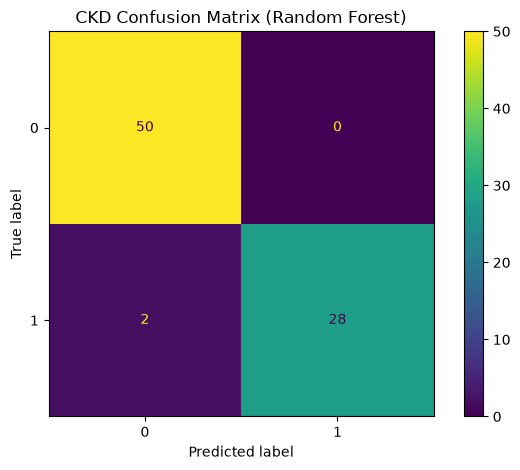

In [8]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("CKD Confusion Matrix (Random Forest)")
plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()